# Does un-broadcast `[-1]` (1 hop) really equal `[-1,-1,-1]` (3 hops)?

To test the real claim — that the **wrong** 1-hop sampling gives the **same GCN output** as
correct 3-hop sampling — we bypass the resolver and feed raw `num_neighbors` straight to two
`GraphJointDataSplitter`s, then run the **trained** GCN's real `inference()` on the *same seeds*
through both and compare `qsm`.

The splitter uses `NeighborLoader(..., directed=False)` (induced subgraph: all edges among
sampled nodes), which is central to what we find below.

In [1]:
import numpy as np, torch
import matplotlib.pyplot as plt
from perturb_utils import load_crc_slide, split_indices
from cellina._spatial_utils import spatial_neighbors
from cellina import CellinaGCN
from cellina._edge_data_splitter import GraphJointDataSplitter

torch.manual_seed(0); np.random.seed(0)
plt.rcParams['figure.dpi'] = 95

labels_key='coarse_type'; domains_key='typ'
holdout_celltype='Epithelial'

adata = load_crc_slide(slide_id=232, data_dir='.')
train_idx, val_idx, test_idx = split_indices(
    adata, holdout_celltype=holdout_celltype, labels_key=labels_key,
    domains_key=domains_key, holdout_domains=('CRC',))
adata.X = adata.layers['counts'].copy()
spatial_neighbors(adata, bandwidth=900, max_neighbours=20,
                  standardize=False, test_indices=test_idx)
print('adata', adata.shape)

adata (111989, 3000)


In [2]:
# Train a fresh model each run so the experiment never reuses a saved model's stale init_params.
CellinaGCN.setup_anndata(
    adata,
    batch_key=None,
    labels_key=labels_key,
    domains_key=domains_key,
    layer='counts',
    spatial_connectivities_key='spatial_connectivities',  # written by spatial_neighbors above
)

model = CellinaGCN(adata, n_latent=24, convolution_type='gat',
                   discriminator_lambda=1.0, link_prediction_weight=1.0,
                   spatial_loss_type='supcon', n_layers=2, num_neighbors=[-1, -1, -1],
                   condition_on_intrinsic=False, x_spatial_layer=None)

model.train(
    max_epochs=100,
    check_val_every_n_epoch=1,
    early_stopping=True,
    early_stopping_patience=5,
    early_stopping_monitor='vae_loss_validation',
    plan_kwargs={'lr': 1e-3, 'weight_decay': 0.0001, 'normalize_losses': True},
    datasplitter_kwargs={"external_indexing": [train_idx, val_idx, test_idx]},
    batch_size=1024,
    devices=[1]
)
mod = model.module.cpu().eval()
print('num_neighbors =>', model._num_neighbors)

INFO     cellina: The CellinaGCN model has been initialized with adversarial domain forgetting with edge prediction


/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)
/data/ddimitrov/repos/cellina/src/cellina/_cellina_gcn_model.py:686: UserWarning: len(num_neighbors)=3 != n_layers=2; NeighborLoader samples len(num_neighbors) hops (a length-1 list = 1 hop), differing from the GCN depth -- the receptive field is truncated/padded. Pass a length-2 list to silence. Got [-1, -1, -1].
  warnings.warn(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more 

Training:   0%|          | 0/100 [00:00<?, ?it/s]

Monitored metric vae_loss_validation did not improve in the last 5 records. Best score: 405.098. Signaling Trainer to stop.
num_neighbors => [-1, -1, -1]


In [3]:
B = 1024
sp1 = GraphJointDataSplitter(model.adata_manager, num_neighbors=[-1],         batch_size=B)
sp3 = GraphJointDataSplitter(model.adata_manager, num_neighbors=[-1, -1, -1], batch_size=B)

rng = np.random.default_rng(0)
held = np.zeros(adata.n_obs, bool); held[test_idx] = True
pool = np.where(~held)[0]
seeds = np.sort(rng.choice(pool, size=B, replace=False))

@torch.no_grad()
def run(splitter, sd, bsz):
    loader = splitter.create_inference_loader(sd, batch_size=bsz, shuffle=False)
    batch = next(iter(loader))['node_batch']; bs = int(batch['batch_size'])
    out = mod.inference(x=batch['X'].cpu(), batch_index=batch['batch_label'].cpu(),
                        edge_index=batch['edge_index'].cpu(), batch_size=bs)
    return (out['qsm'].cpu().numpy(), np.asarray(batch['node_indices'].cpu()),
            int(batch['X'].shape[0]), int(batch['edge_index'].shape[1]))

qsm1, sid1, nn1, ne1 = run(sp1, seeds, B)
qsm3, sid3, nn3, ne3 = run(sp3, seeds, B)
qsm1, qsm3 = qsm1[np.argsort(sid1)], qsm3[np.argsort(sid3)]
print(f'1-hop subgraph: {nn1:,} nodes  {ne1:,} edges')
print(f'3-hop subgraph: {nn3:,} nodes  {ne3:,} edges  (x{nn3/nn1:.1f} nodes)')

/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(


1-hop subgraph: 18,853 nodes  261,057 edges
3-hop subgraph: 60,319 nodes  1,145,902 edges  (x3.2 nodes)


per-seed L2 diff   : median=0.1289  max=2.1313
relative diff      : median=0.050  max=1.029
cosine similarity  : median=1.0000  min=-0.2994
fraction identical : 0.002


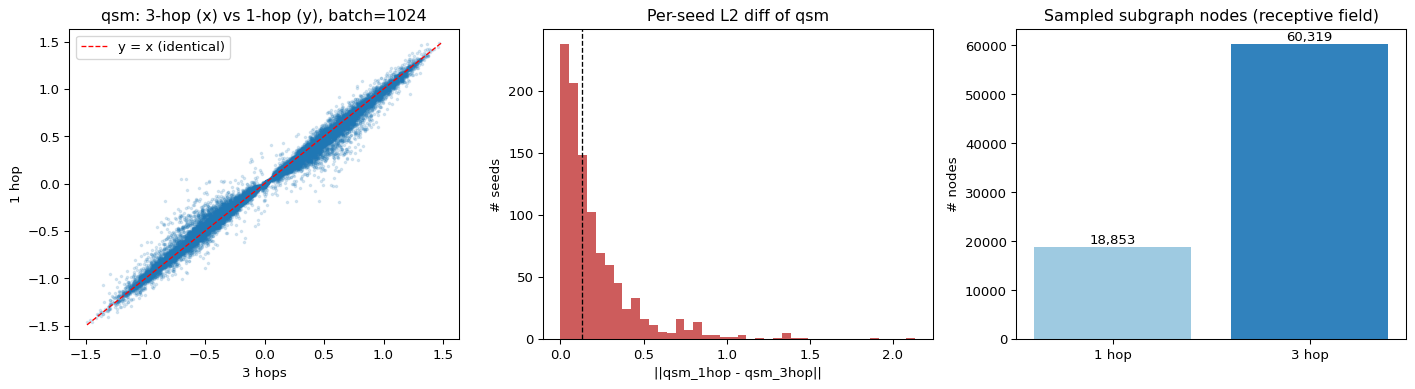

In [4]:
per_seed = np.linalg.norm(qsm1 - qsm3, axis=1)
rel = per_seed / (np.linalg.norm(qsm3, axis=1) + 1e-9)
cos = (qsm1*qsm3).sum(1) / (np.linalg.norm(qsm1,axis=1)*np.linalg.norm(qsm3,axis=1) + 1e-9)
print('per-seed L2 diff   : median=%.4f  max=%.4f' % (np.median(per_seed), per_seed.max()))
print('relative diff      : median=%.3f  max=%.3f' % (np.median(rel), rel.max()))
print('cosine similarity  : median=%.4f  min=%.4f' % (np.median(cos), cos.min()))
print('fraction identical : %.3f' % (per_seed < 1e-5).mean())

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
a, b = qsm3.ravel(), qsm1.ravel()
ax[0].scatter(a, b, s=3, alpha=0.15)
lim = [min(a.min(),b.min()), max(a.max(),b.max())]
ax[0].plot(lim, lim, 'r--', lw=1, label='y = x (identical)')
ax[0].set(title=f'qsm: 3-hop (x) vs 1-hop (y), batch={B}', xlabel='3 hops', ylabel='1 hop'); ax[0].legend()
ax[1].hist(per_seed, bins=40, color='indianred')
ax[1].axvline(np.median(per_seed), color='k', ls='--', lw=1)
ax[1].set(title='Per-seed L2 diff of qsm', xlabel='||qsm_1hop - qsm_3hop||', ylabel='# seeds')
ax[2].bar(['1 hop','3 hop'], [nn1, nn3], color=['#9ecae1','#3182bd'])
ax[2].set(title='Sampled subgraph nodes (receptive field)', ylabel='# nodes')
for i,v in enumerate([nn1,nn3]): ax[2].text(i, v, f'{v:,}', ha='center', va='bottom')
plt.tight_layout(); plt.show()

## The clincher: the near-equality is a batch-overlap artifact

If 1-hop only looks like 3-hop because batch-mates' neighborhoods overlap and `directed=False`
reconstructs the missing edges, then shrinking the batch should break it: fewer seeds, less
overlap, so 1-hop genuinely misses the 2nd/3rd-hop context.

batch=    8:  median rel=0.064  max=0.440  1hop/2hop nodes=0.16
batch=   32:  median rel=0.068  max=0.641  1hop/2hop nodes=0.16
batch=  128:  median rel=0.069  max=0.638  1hop/2hop nodes=0.18
batch=  512:  median rel=0.065  max=0.995  1hop/2hop nodes=0.24
batch= 2048:  median rel=0.041  max=1.307  1hop/2hop nodes=0.46


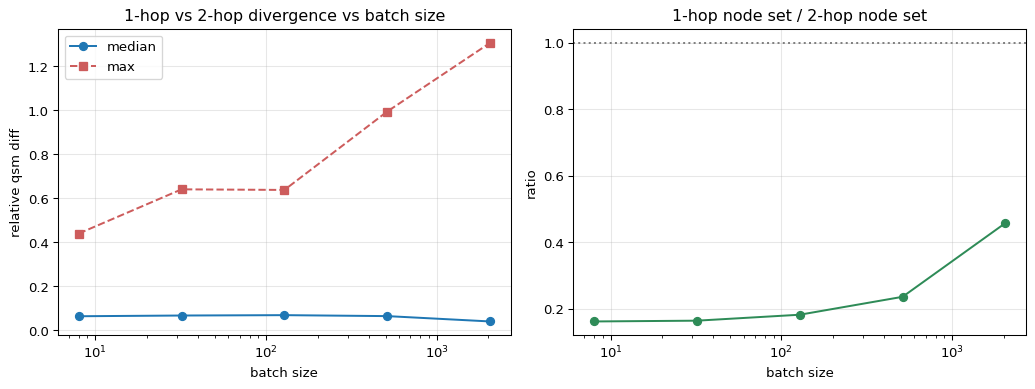

In [5]:
sizes = [8, 32, 128, 512, 2048]
med_rel, max_rel, node_ratio = [], [], []
for bsz in sizes:
    sd = np.sort(rng.choice(pool, size=bsz, replace=False))
    q1, i1, n1, _ = run(sp1, sd, bsz)
    q3, i3, n3, _ = run(sp3, sd, bsz)
    q1, q3 = q1[np.argsort(i1)], q3[np.argsort(i3)]
    d = np.linalg.norm(q1 - q3, axis=1) / (np.linalg.norm(q3, axis=1) + 1e-9)
    med_rel.append(np.median(d)); max_rel.append(d.max()); node_ratio.append(n1 / n3)
    print('batch=%5d:  median rel=%.3f  max=%.3f  1hop/2hop nodes=%.2f'
          % (bsz, np.median(d), d.max(), n1/n3))

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].plot(sizes, med_rel, 'o-', label='median'); ax[0].plot(sizes, max_rel, 's--', color='indianred', label='max')
ax[0].set(xscale='log', title='1-hop vs 2-hop divergence vs batch size', xlabel='batch size', ylabel='relative qsm diff')
ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(sizes, node_ratio, 'o-', color='seagreen'); ax[1].axhline(1.0, color='grey', ls=':')
ax[1].set(xscale='log', title='1-hop node set / 2-hop node set', xlabel='batch size', ylabel='ratio'); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Conclusion.** 1-hop and 3-hop are *not* equivalent — no seed matches exactly, and at small
batches (or sparse regions, or per-cell inference) the divergence is large. The near-equality at
`batch_size=512` is a coincidence of dense batch overlap + `directed=False` induced sampling
papering over the missing hops. Matching `len(num_neighbors)` to `n_layers` guarantees the
correct receptive field for **every** seed regardless of batch composition — which is why the
default is `[-1] * n_layers` and any other length (e.g. a bare `[-1]`) warns that the sampled
hops disagree with the GCN depth.